# Métodos de diferencias finitas para problemas de valor de dos puntos

Basado en el trabajo de [Anne Kværnø y André Massing](https://www.math.ntnu.no/emner/TMA4125/2021v/lectures/TwoPointBoundaryProblems.pdf).

Fecha: **25 de marzo de 2025**

## Introducción

En esta nota se presentará el método de diferencias finitas para resolver ecuaciones diferenciales parciales (PDE).

En términos generales, un método de diferencias finitas consta de los siguientes pasos: 
1. Discretiza el dominio en el que se define la ecuación. 
2. En cada punto de la cuadrícula, reemplace las derivadas con una aproximación, utilizando los valores en los puntos de la cuadrícula vecinos. 
3. Reemplazar las soluciones exactas por sus aproximaciones. 
4. Resuelve el sistema de ecuaciones resultante.

Primero veremos cómo encontrar aproximaciones a la derivada de una función y luego cómo
se pueden usar para resolver problemas de valores en la frontera como
$$
\begin{cases}
u^{\prime\prime}\left(x\right)+
p\left(x\right)u^{\prime}\left(x\right)+
q\left(x\right)u\left(x\right)=
r\left(x\right) &
\text{en }\left(a,b\right). \\
u\left(a\right)=u_{a},\quad u\left(b\right)=u_{b}. &
\end{cases}
$$
y ecuaciones diferenciales parciales dependientes del tiempo como la ecuación del calor
$$
\frac{\partial u}{\partial t}=\alpha
\frac{\partial^{2} u}{\partial x^{2}}.
$$
Sin embargo, la técnica descrita aquí es aplicable a varias otras EDPs, 
y, por tanto, es importante intentar comprender la idea subyacente.

## Diferenciación numérica

Esta es la herramienta principal para los métodos de diferencias finitas.

Dada una función $u$ suficientemente suave.
¿Cómo podemos encontrar una aproximación a
$u^{\prime}\left(x\right)$ o $u^{\prime\prime}\left(x\right)$ en algún punto dado $x$,
simplemente usando la evaluación de la función en sí?

[La derivada de $u$](https://wiki.math.ntnu.no/tma4100/tema/differentiation?&#definisjonen_av_den_deriverte_gitt_som_en_grenseverd) se define como
$$
u^{\prime}\left(x\right)=
\lim_{h\to 0}
\frac{u\left(x+h\right)-u\left(x\right)}{h}.
$$

Dado un valor suficientemente pequeño de $h$, el lado derecho se puede utilizar como
una aproximación a la *primera derivada* $u^{\prime}\left(x\right)$. 
Una pequeña colección de las aproximaciones más utilizadas a la derivada de primer
orden $u^{\prime}\left(x\right)$ es

$$
u^{\prime}\left(x\right)\approx
\begin{cases}
\dfrac{u\left(x+h\right)-u\left(x\right)}{h}\coloneqq
\partial^{+}u\left(x\right) & \text{Diferencia hacia adelante.}\\
\dfrac{u\left(x\right)-u\left(x-h\right)}{h}\coloneqq
\partial^{-}u\left(x\right) & \text{Diferencia hacia atrás.} \\ 
\dfrac{u\left(x+h\right)-u\left(x-h\right)}{2h}\coloneqq
\partial^{\circ}u\left(x\right) & \text{Diferencia central.}
\end{cases}
$$

<center>
<figure style="width: 600px;">
  <img src="https://i.imgur.com/kgInUna.png" alt="Description of the image" style="width: 100%;">
  <figcaption style="text-align: center; font-size: 0.9em; color: #555;">
    Recuperado de https://gitlab.com/carlosal1015/partial-differential-equations/-/raw/main/utils/fdm/derivatives.py
  </figcaption>
</figure>
</center>

El primero se toma directamente de la definición, al igual que el segundo, y el tercero es solo la media de los dos primeros.

Una aproximación común a la *segunda derivada* es
$$
u^{\prime\prime}\left(x\right)\approx
\partial^{+}\partial^{-}u\left(x\right)=
\frac{u\left(x+h\right)-2u\left(x\right)+u\left(x-h\right)}{h^{2}}.
$$

**Ejemplo numérico 1:** 
Probar el método en la función
$u\left(x\right)=\operatorname{sen}\left(x\right)$ en el punto $x=\frac{\pi}{4}$. 
Comparar con la derivada exacta. Pruebe diferentes tamaños de paso, por ejemplo, $h=0.1$, $h=0.01$ y $h=0.001$. 
Observe cómo el error en cada caso cambia con $h$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {
        "figure.figsize": (8.0, 4.0),
        "axes.grid": True,
        "lines.markersize": 8,
        "lines.linewidth": 2,
        "font.size": 14,
    }
)

In [2]:
# Diferenciación numérica

# Diferencia hacia adelante
def diff_forward(u, x, h=0.1):
    return (u(x + h) - u(x)) / h


# Diferencia hacia atrás
def diff_backward(u, x, h=0.1):
    return (u(x) - u(x - h)) / h


# Diferencia central para f'(x):
def diff_central(u, x, h=0.1):
    return (u(x + h) - u(x - h)) / (2 * h)


# Diferencia central para f''(x):
def diff2_central(u, x, h=0.1):
    return (u(x + h) - 2 * u(x) + u(x - h)) / h**2

In [3]:
# Ejemplo numérico 1
x = np.pi / 4
du_exact = np.cos(x)
ddu_exact = -np.sin(x)
for h in [0.1, 0.01, 0.001]:
    u = np.sin
    du = diff_forward(u, x, h)
    print(f"Approximations to the first derivative for h = {h}")
    print(f"Forward difference:  du  = {du:12.8f},  Error = {du_exact - du:10.3e}")
    du = diff_backward(u, x, h)
    print(f"Backward difference: du  = {du:12.8f},  Error = {du_exact - du:10.3e}")
    du = diff_central(u, x, h)
    print(f"Central difference:  du  = {du:12.8f},  Error = {du_exact - du:10.3e}")
    print("Approximation to the second derivative")
    ddu = diff2_central(u, x, h)
    print(f"Central difference:  ddu = {ddu:12.8f}, Error = {ddu_exact - ddu:10.3e}")

Approximations to the first derivative for h = 0.1
Forward difference:  du  =   0.67060297,  Error =  3.650e-02
Backward difference: du  =   0.74125475,  Error = -3.415e-02
Central difference:  du  =   0.70592886,  Error =  1.178e-03
Approximation to the second derivative
Central difference:  ddu =  -0.70651772, Error = -5.891e-04
Approximations to the first derivative for h = 0.01
Forward difference:  du  =   0.70355949,  Error =  3.547e-03
Backward difference: du  =   0.71063050,  Error = -3.524e-03
Central difference:  du  =   0.70709500,  Error =  1.179e-05
Approximation to the second derivative
Central difference:  ddu =  -0.70710089, Error = -5.893e-06
Approximations to the first derivative for h = 0.001
Forward difference:  du  =   0.70675311,  Error =  3.537e-04
Backward difference: du  =   0.70746022,  Error = -3.534e-04
Central difference:  du  =   0.70710666,  Error =  1.179e-07
Approximation to the second derivative
Central difference:  ddu =  -0.70710672, Error = -5.901e-0

## Análisis de errores

En este caso, el análisis del error es bastante simple: realice una expansión de Taylor del error alrededor de $x$. 
La expansión de Taylor se convierte en una serie de potencias en $h$.

La expansión para el error de la diferencia directa es
\begin{align*}
e\left(x;h\right) &=
u^{\prime}\left(x\right)-
\frac{u\left(x+h\right)-u\left(x\right)}{h}. \\
       &=
u^{\prime}\left(x\right)-
\frac{\left[u\left(x\right)+u^{\prime}\left(x\right)h+\frac{1}{2}u^{\prime\prime}\left(\xi\right)h^{2}\right]-u\left(x\right)}{h}. \\
       &=
       -\frac{1}{2}u^{\prime\prime}\left(\xi\right)h,\quad\text{ para algún }\xi\in\left(x,x+h\right).
\end{align*}

La expansión del error de la diferencia central es un poco más complicada
\begin{align*}
e\left(x; h\right) &=
u^{\prime}\left(x\right)-
\frac{u\left(x+h\right)-u\left(x-h\right)}{2h}. \\ 
        &=
u^{\prime}\left(x\right)-
\frac{\left[u(x)+u^{\prime}\left(x\right)h+\frac{1}{2}u^{\prime\prime}\left(x\right)h^{2}+\frac{1}{6}u^{\prime\prime\prime}\left(\xi_1\right)h^{3}\right]-\left[u(x)-u'(x)h + \frac{1}{2} u''(x)h^2 - \frac{1}{6} u'''(\xi_2)h^3\right]}{2h}. \\ 
        &=
        -\frac{1}{12}
        \left[u^{\prime\prime\prime}\left(\xi_1\right)+u^{\prime\prime\prime}(\xi_2)\right]h^{2}.  \\ 
        &=
        -\frac{1}{6}
        u^{\prime\prime\prime}\left(\eta\right)h^{2},\quad\text{ para algún }\eta\in\left(x-h,x+h\right).
\end{align*}

En el último paso, los dos términos restantes se combinaron mediante el teorema del valor intermedio. 
El error de aproximación de la derivada de segundo orden se puede encontrar de manera similar.

**Problema 1**: Utilice la expansión de Taylor para demostrar que
$\forall u\in C^{4}\left(\left[a,b\right]\right)$:
$\left|\partial^{+}\partial^{-}u\left(x\right)-u^{\prime\prime}\left(x\right)\right|=\mathcal{O}\left(h^2\right)$.

**Recordatorio.** 
El orden de una aproximación es $p$ si y solamente si existe una constante $C$ independiente de $h$ tal que
$\forall h>0$: $\left|e\left(h;x\right)\right|\leq Ch^{p}$.

En la práctica, es suficiente demostrar que la expansión de potencia del error satisface
$$
e\left(x,h\right)=
C_{p}h^{p}+
C_{p+1}h^{p+1}+
\dotsm,\text{ con }C_{p}\neq 0.
$$
Las aproximaciones hacia adelante y hacia atrás son de orden $1$, las diferencias centrales de orden $2$.

Usaremos mucho estas fórmulas en la secuela, así que resumamos los resultados, incluidos los términos de error.

**Fórmulas de diferencias para derivadas:**

\begin{align*}
   u^{\prime}\left(x\right) &= \left\{
   \begin{array}{ll} \displaystyle
     \underbrace{\frac{u(x+h)-u(x)}{h}}_{\partial^+u(x)} - \frac{h}{2}u''(\xi), \ & \text{Diferencia hacia adelante} \\ 
      \displaystyle 
     \underbrace{\frac{u(x)-u(x-h)}{h}}_{\partial^-u(x)} + \frac{h}{2}u''(\xi), & \text{Diferencia hacia atrás} \\ 
     \displaystyle
     \underbrace{\frac{u(x+h)-u(x-h)}{2h}}_{\partial^{\circ}u(x)} - \frac{h^2}{6}u'''(\xi).\qquad  & \text{Diferencia central} 
   \end{array}
   \right. \\
   u''(x) & = 
  \underbrace{\frac{u(x+h)-2u(x)+u(x-h)}{h^2}}_{\partial^+\partial^-u(x)} - \frac{h^2}{12}u^{(4)}(\xi), \qquad  
\text{Diferencia central}
\end{align*}

## Método de diferencias finitas para el problema de Poisson 1d

Comenzamos nuestro viaje con el siguiente problema.
Sea $\left[a,b\right]\subset\mathbb{R}$ un intervalo finito,
junto con una función $f\colon\left[a,b\right]\to\mathbb{R}$.
Entonces, el _problema de valor de frontera de dos puntos_ es encontrar un $u\colon\left[a,b\right]\to\mathbb{R}$ 
tal que

\begin{gather}
- u''\left(x\right)=f\left(x\right)\quad \forall x\in\left(a,b\right),
\tag{1a}
\\
u(a) = u_a, \quad  u(b) = u_b
\tag{1b}
\end{gather}
donde $u_{a}$ y $u_{b}$ reciben valores dados.
_Para el resto de esta sección asumiremos que_ $a=0$, $b=1$.

Tenga en cuenta que estas son ecuaciones diferenciales ordinarias de __segundo orden__
y, por lo tanto, requieren dos valores de suma para determinar una solución completa, uno en cada punto frontera.

Este es el contraste del problema de valor inicial de segundo orden
\begin{align*}
u'' &= f(t,u(t), u'(t)) \quad \forall\; t \in (0,1)
\\
u(0) &= u_0,
\\
u'(0) &= u_1
\end{align*}
donde tenemos dos condiciones en el punto final izquierdo.
La razón principal es que en el primer caso, $x$ es una variable espacial, 
mientras que en el último caso, $t$ es una variable de tiempo.

En lugar de intentar calcular $u\left(x\right)$ exactamente,
ahora intentaremos calcular una aproximación numérica $u_{\Delta}$ de
$u\left(x\right)$.
Como muchas veces antes, comenzamos definiendo $n+1$ puntos equidistantes
$\left\{x_{i}\right\}_{i=0}^{n}$
con un tamaño de malla $h=\frac{b-a}{n}$ de modo que
$$
x_{i}\coloneqq a+ih \quad
\text{para } i = 0, 1, \ldots, n.
$$

Entonces la derivada de segundo orden $u^{\prime\prime}$ puede aproximarse
mediante el __operador de diferencia central__ definido por

\begin{align}
\partial^{+}\partial^{-}u\left(x_{i}\right)\coloneqq
\frac{u\left(x_{i}+h\right)-2u\left(x_{i}\right)+u\left(x_{i}-h\right)}{h^2}
\approx u^{\prime\prime}\left(x_{i}\right)=
-f\left(x_{i}\right).
\end{align}

Now the idea is to numerically solve for the two-point boundary value problem by associating an unknown variable
$U_{i}\coloneqq u_{\Delta}\left(x_{i}\right)$ to every grid point $x_i$ for $i=0,\ldots N$.
Of course, the goal is to find an $U_{i}\approx u\left(x_{i}\right)$.
Keeping in mind that $-u^{\prime\prime}=f$, we demand that at the __internal__ grid points
$\left\{x_{i}\right\}_{i=1}^{N}$ the unknowns satisfy

\begin{align}
-\partial^{+}\partial^{-}U_{i}=
-\frac{U_{i+1}-2U_{i}+U_{i-1}}{h^2}
=f\left(x_{i}\right)\text{ para }i=1,\ldots N-1.
\end{align}

Tenga en cuenta que en $x_{0}$ y $x_{N}$, $\partial^{+}\partial^{-}U_{i}$ no está bien definido 
ya que no tenemos un punto a la izquierda (respectivamente a la derecha) de $x_{0}$ (respectivamente $x_{N}$).
Esto conduce al sistema lineal *no cuadrado* $N-1\times N+1$ de la forma

\begin{align}
\dfrac{1}{h^2}
\underbrace{
\begin{bmatrix}
-1 & 2  & -1 & & &
\\
  & -1 & 2  & -1 & & 
\\
  &    & -1 & 2 & -1 & & 
\\
 &     &    & \ddots &\ddots & \ddots &
\\
&      &    &        &  -1 & 2 & -1
\end{bmatrix}
}_{\widetilde{A}}
\underbrace{
\begin{bmatrix}
U_0
\\
U_1
\\
U_2
\\
U_3
\\
\vdots
\\
U_{N}
\end{bmatrix}
}_{\widetilde{U}}
=
\underbrace{
\begin{bmatrix}
f(x_1)
\\
f(x_2)
\\
f(x_3)
\\
\vdots
\\
f(x_{N-1})
\end{bmatrix}
}_{\widetilde{F}}
\end{align}

Por reflejo, inmediatamente preguntamos si este sistema _siempre tiene solución_
y tiene una _solución única_.
Desafortunadamente, la matriz $\widetilde{A}$ anterior no es cuadrada y tiene
más columnas que filas y, por lo tanto, tiene un núcleo no trivial.
Un ejemplo es $U_{0}=U_{1}=U_{2}=\ldots U_{N-1}=U_{N}=c$ para cualquier constante $c$.
¡Ahí es donde entran en juego las condiciones de frontera!

Entonces, para cerrar el sistema, incorporemos la condición de frontera estableciendo
$$
U_{0}=u_{a},\quad
U_{N}=u_{b}.
$$
These trivial equations can be added to the system above, leading to final problem:

Encuentre $U=[U_{0},\ldots,U_{N}]\in\mathbb{R}^{N+1}$ tal que

\begin{align}
\dfrac{1}{h^2}
\underbrace{
\begin{bmatrix}
h^2
\\
-1 & 2  & -1 & & &
\\
  & -1 & 2  & -1 & & 
\\
  &    & -1 & 2 & -1 & & 
\\
 &     &    & \ddots &\ddots & \ddots &
\\
&      &    &        &  -1 & 2 & -1
\\
&      &    &        &  &  & h^2
\end{bmatrix}
}_{{A}}
\underbrace{
\begin{bmatrix}
U_0
\\
U_1
\\
U_2
\\
U_3
\\
\vdots
\\
U_{N-1}
\\
U_{N}
\end{bmatrix}
}_{{U}}
=
\underbrace{
\begin{bmatrix}
u_a
\\
f(x_1)
\\
f(x_2)
\\
f(x_3)
\\
\vdots
\\
f(x_{N-1})
\\
u_b
\end{bmatrix}
}_{{F}}
\end{align}

## Implementación

In [4]:
def fdm_poisson1d_matrix(N):
    """Calcula la matriz de diferencias finitas para el problema de Poisson en 1D

    Parámetros:
    N (int): Número de puntos de la malla :math:`\{x_i}_{i=0}^N` contando desde 0.

    Returns:
    A (ndarray): Matriz de diferencias finitas

    """
    # Tamaño de la malla
    h = 1.0 / N

    # Defina la matriz cero A del tamaño correcto
    A = np.zeros((N + 1, N + 1))

    # Defina la parte tridiagonal de A
    hh = h * h
    for i in range(1, N):
        A[i, i - 1] = -1 / hh
        A[i, i] = 2 / hh
        A[i, i + 1] = -1 / hh

    # Establezca a_00 = a_NN en 1 para incorporar la condición de frontera
    A[0, 0] = 1
    A[N, N] = 1

    return A


def apply_bcs(F, bcs):
    "Incorporar la condición de frontera en el vector rhs"
    F[0], F[-1] = bcs[0], bcs[1]

In [5]:
# Solución de referencia analítica
def u(x):
    return np.sin(2 * np.pi * x)


def f(x):
    return (2 * np.pi) ** 2 * np.sin(2 * np.pi * x)


N = 10

# Defina puntos de la malla
x = np.linspace(0, 1, N + 1)
xfine = np.linspace(0, 1, 10 * N)

# Calcular A y F
A = fdm_poisson1d_matrix(N)
F = f(x)
print(A)
print(F)

[[   1.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.]
 [-100.  200. -100.    0.    0.    0.    0.    0.    0.    0.    0.]
 [   0. -100.  200. -100.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0. -100.  200. -100.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0. -100.  200. -100.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0. -100.  200. -100.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0. -100.  200. -100.    0.    0.    0.]
 [   0.    0.    0.    0.    0.    0. -100.  200. -100.    0.    0.]
 [   0.    0.    0.    0.    0.    0.    0. -100.  200. -100.    0.]
 [   0.    0.    0.    0.    0.    0.    0.    0. -100.  200. -100.]
 [   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.]]
[ 0.00000000e+00  2.32048317e+01  3.75462063e+01  3.75462063e+01
  2.32048317e+01  4.83471178e-15 -2.32048317e+01 -3.75462063e+01
 -3.75462063e+01 -2.32048317e+01 -9.66942355e-15]


In [6]:
# Incorporar condiciones de frontera
bcs = [u(0), u(1)]
apply_bcs(F, bcs)

# Resolver AU = F
# (Introduciremos un solucionador disperso cuando analicemos problemas 2D.)
U = np.linalg.solve(A, F)

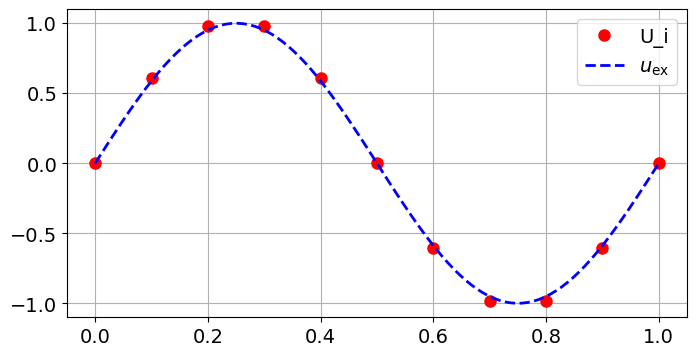

In [7]:
# Grafique una solución discreta en la malla de discretización elegida
plt.plot(x, U, "or", label="U_i")
plt.plot(xfine, u(xfine), "--b", label="$u_{\mathrm{ex}}$")
plt.legend()
plt.show()

**Problema 2** 

Aplique el método de __soluciones manufacturadas__: tome una función conocida
$u\left(x\right)$ y calcule los datos correspondientes $f$ y $u_{a}$, $u_{b}$
tales que $u$ es la solución al problema de la frontera de dos puntos (1a)--(1b)

Por ejemplo, puede elegir $u\left(x\right)=\cos\left(2\pi x\right)$. 
¿Qué es entonces $f=-u^{\prime\prime}$, $u_{a}=u\left(0\right)$,
$u_{b}=u\left(1\right)$?

Después de haber elegido su solución manufacturada favorita (suave), puede calcular el error
$$
\mathrm{err}\left(h\right)=
\mathrm{err}\left(N\right)=
\max_{i\in\left\{0,\ldots,N\right\}}
\left|U_{i}-u\left(x_{i}\right)\right|
$$
en función de $h=\frac{1}{N}$.

Para $N_{1}=5$, $N_{2}=10$, $N_{3}=20$, $N_{4}=40$, $N_{5}=80$.
* Calcule y grafique la solución numérica y la solución analítica.
* Registre el resultado $\mathrm{err}\left(N\right)$.

Al final de su experimento, calcule el __orden de convergencia experimental__ 
para cada nivel de refinamiento $N_2, \ldots, N_5$ definido
$$
\text{EOC}
\left(N_{i}\right)=
\frac{
    \log\left(\mathrm{err}\left(N_{i}\right)\right)-
    \log\left(\mathrm{err}\left(N_{i-1}\right)\right)
}{
    \log\left(N_{i-1}\right)-
    \log\left(N_{i}\right)
}.
$$
¿Qué orden de convergencia espera y cuál obtiene?

## General two point boundary problems (BVP)

A continuación, discutiremos la solución numérica de un problema de valor de frontera de dos puntos de la forma
$$
u^{\prime\prime}+
p\left(x\right)u^{\prime}+
q\left(x\right)u=
r\left(x\right),\qquad
a\leq x\leq b,\qquad
u\left(a\right)=u_{a},\quad
u\left(b\right)=u_{b},
$$
donde $p$, $q$ son funciones de $x$ dadas y los valores de frontera $u_{a}$ y $u_{b}$ son constantes dadas.

Como antes, se construye un método de diferencias finitas para este problema con los siguientes pasos:

**Paso 1:** 
Dado el intervalo $\left[a,b\right]$. 
Elija algunos $N\in\mathbb{N}$, defina el tamaño de paso
$h=\frac{b-a}{N}$ y los puntos de la malla $x_{i}=a+ih$, $i=0,1,\dotsc,N$.

**Paso 2:**
Para cada punto interior de la malla $x_{i}$, $i=1,\dotsc,N-1$, reemplace las derivadas por sus aproximaciones en el problema de valor de frontera.
El resultado es
$$
\frac{u\left(x_{i}+h\right)-2u\left(x_{i}\right)+u\left(x_{i}-h\right)}{h^2}+
p\left(x_{i}\right)
\frac{u\left(x_{i}+h\right)-u\left(x_{i}-h\right)}{2h}+
q\left(x_{i}\right)u\left(x_{i}\right)+
\mathcal{O}\left(h^{2}\right)=
r\left(x_{i}\right)
$$
para cada $i=1,2\dotsc,N-1$, y el término $\mathcal{O}\left(h^2\right)$ representa los errores en las fórmulas de diferencia.

**Paso 3:**
Ignore el término de error y reemplace la solución exacta $u\left(x_{i}\right)$ por su aproximación numérica (y aún desconocida) $U_{i}$
$$
\frac{U_{i+1}-2U_{i}+U_{i-1}}{h^2}+
p\left(x_{i}\right)
\frac{U_{i+1}-U_{i-1}}{2h}+
q\left(x_{i}\right)U_{i}=
r\left(x_{i}\right), \qquad i=1,\dotsc,N-1.
$$
Esta es la *discretización* del problema de valor de frontera.

Si ahora incluimos los dos valores de frontera como ecuaciones
$$
U_{0}=u_{a}
\text{ y }
U_{N}=u_{b},
$$
la discretización es un sistema lineal de ecuaciones
$$
AU=b,
$$
donde $A\in\mathbb{R}^{\left(N+1\right)\times\left(N+1\right)}$ es una matriz y
$U={\left[U_{0},\dotsc,U_{N}\right]}^{T}$.
O más específico, al multiplicar las ecuaciones por $h^{2}$ terminamos con:

$$
A =  \left[ \begin{array}{ccccccc}
      1 & 0 & &  \\ 
      v_1 & d_1 & w_1 & & &  \\ 
        & v_2 & d_2 & w_2 &  \\ 
        & & v_3 & \ddots & \ddots & \\ 
        & & & \ddots & \ddots & w_{N-2} \\ 
        & & & & v_{N-1} & d_{N-1} & w_{N-1}  \\ 
        & & & & &  0 & 1
    \end{array} \right]
    \text{ con }
    \begin{array}{l}
    \displaystyle v_i =1-\frac{h}{2}p(x_i) \\ 
    \displaystyle d_i = -2 + h^2q(x_i) \\ 
    \displaystyle w_i = 1+\frac{h}{2}p(x_i)
    \end{array}.
$$

El lado derecho $b$ está dado por
$$
b=
\left[
    u_{a},
    h^{2}r\left(x_{1}\right),
    \dotsc,
    h^{2}r\left(x_{N-1}\right),
    u_{b}
\right]^{T}.
$$
Obviamente, la primera y la última ecuaciones son triviales de resolver y, por lo tanto, a menudo se incluyen en el lado derecho.

**Paso 4:**
Resuelva $AU=b$ con respecto a $U$.

**Ejemplo 1:**
Consideremos la ecuación
$$
u^{\prime\prime}+
2u^{\prime}-
3u=9x,
\quad
u\left(0\right)=
u_{a}=1,\quad
u\left(1\right)=u_{b}=
e^{-3}+2e-5\approx 0.486351,
$$
con solución exacta $u\left(x\right)=e^{-3x}+2e^{x}-3x-2$.

Elija $N$, sea $h=\frac{1}{N}$.
Utilice las diferencias centrales para $u^{\prime}$ y $u^{\prime\prime}$, tales que
$$
\frac{
    u\left(x_{i}+h\right)-
    2u\left(x_{i}\right)+
    u\left(x_{i}-h\right)
}{h^2}+
2\frac{u\left(x_{i}+h\right)-u\left(x_{i}-h\right)}{2h}-
3u\left(x_{i}\right)+
\mathcal{O}\left(h^{2}\right)=9x_{i},\quad i=1,\dotsc, N.
$$

Sea $U_{i}\approx u\left(x_{i}\right)$.
Multiplica por $h^{2}$ en ambos lados, incluye $U_{0}=u_{a}$ o $U_{N}=u_{b}$ y limpie el desorden:

\begin{align*}
 U_{0} &= 1, \\ 
 \left(1-h\right)U_{i-1}+
 \left(-2-3h^2\right)U_{i}+
 \left(1+h\right)U_{i+1} &=
 9x_{i}h^2, && i=1, \ldots, N-1, \\ 
 U_{N} &= 0.486351.
\end{align*}

Para ser aún más concreto, para $N=4$, obtenemos $h=0.25$.
El sistema lineal de ecuaciones se convierte en
$$
\begin{bmatrix}
  1 & 0 & 0 & 0 & 0\\ 
  0.75 & -2.1875 & 1.25 & 0 & 0\\ 
  0 & 0.75 & -2.1875 & 1.25 & 0\\ 
  0 & 0 & 0.75 & -2.1875 & 1.25 \\ 
  0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
U_{0} \\
U_{1} \\
U_{2} \\
U_{3} \\
U_{4}
\end{bmatrix}=
\begin{bmatrix}
1. \\
0.140625 \\
0.28125  \\
0.421875 \\
0.48635073
\end{bmatrix}.
$$

La primera y la última ecuación son triviales de resolver, por lo que en la práctica tienes un sistema de $3$ ecuaciones con $3$ incógnitas,
$$
\begin{bmatrix}
   -2.1875 & 1.25 & 0 \\ 
  0.75 & -2.1875 & 1.25 \\ 
   0 & 0.75 & -2.1875
\end{bmatrix}
\begin{bmatrix}
U_{1}\\
U_{2}\\
U_{3}
\end{bmatrix}=
\begin{bmatrix}
0.140625-0.75\cdot 1 \\
0.28125  \\
0.421875-1.25 \cdot 0.48635073
\end{bmatrix},
$$

con la solucion
$$
U_{1}\approx
0.293176,\quad
U_{2}\approx
0.025557,\quad
U_{3}\approx
0.093820.
$$

A modo de comparación, la solución analítica en estos puntos es
$$
u\left(0.25\right)\approx 0.290417,\quad
u\left(0.5\right)\approx 0.020573,\quad
u\left(0.75\right)\approx 0.089400.
$$

## Implementación

Para simplificar, la implementación debajo solo se realiza para problemas
de valor de frontera con coeficientes constantes, es decir, $p\left(x\right)=p$
y $q\left(x\right)=q$.
Esto hace que las diagonales, subdiagonales y superdiagonales sean constantes,
excepto en la primera y la última fila. 
Se incluye una función adicional para construir matrices *tridiagonales*,
es decir, matrices donde todas las entradas fuera de la diagonal, subdiagonal y
superdiagonal son iguales a cero.

La implementación consiste en
1. Elija $N$, sea $h=\frac{b-a}{N}$ y $x_{i}=a+ih$, $i=0,\dotsc,N$.
2. Construya la matriz $A\in\mathbb{R}^{\left(N+1\right)\times\left(N+1\right)}$ y el vector $b\in\mathbb{R}^{N+1}$. La matriz $A$ es tridiagonal y, excepto en la primera y última fila, tiene los elementos $v=1-\frac{h}{2}p$ debajo de la diagonal, $d=-2+h^{2}q$ como elementos diagonales y $w=1+\frac{h}{2}p$ encima de la diagonal.
3. Construya el vector $b=\left[b_{0},\dotsc,b_{N}\right]^{T}$ con elementos $b_{i}=h^{2}r\left(x_{i}\right)$ para $i=1,\dotsc,N-1$.
4. Modifique la primera y última fila de la matriz $A$ y el primer y último elemento del vector $b$, dependiendo de las condiciones de frontera.
5. Resuelve el sistema $AU=b$.

In [8]:
def tridiag(v, d, w, N):
    """
    Función de ayuda
    Devuelve una matriz tridiagonal A=tridiag(v, d, w) de dimensión N x N.
    """

    e = np.ones(N)  # array [1,1,...,1] of length N
    A = v * np.diag(e[1:], -1) + d * np.diag(e) + w * np.diag(e[1:], 1)
    return A

In [9]:
np.diag?

Signature:       np.diag(v, k=0)
Call signature:  np.diag(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function diag at 0x7f00e83024b0>
File:            /usr/lib/python3.14/site-packages/numpy/lib/_twodim_base_impl.py
Docstring:      
Extract a diagonal or construct a diagonal array.

See the more detailed documentation for ``numpy.diagonal`` if you use this
function to extract a diagonal and wish to write to the resulting array;
whether it returns a copy or a view depends on what version of numpy you
are using.

Parameters
----------
v : array_like
    If `v` is a 2-D array, return a copy of its `k`-th diagonal.
    If `v` is a 1-D array, return a 2-D array with `v` on the `k`-th
    diagonal.
k : int, optional
    Diagonal in question. The default is 0. Use `k>0` for diagonals
    above the main diagonal, and `k<0` for diagonals below the main
    diagonal.

Returns
-------
out : ndarray
    The extracted diagonal or constructed diagonal array.

See Al

In [10]:
# Ejemplo 1, problema de valor de frontera

# Definir la ecuación
# u^{\prime\prime}+p*u^{\prime}+q*u=r\left(x\right) en el intervalo \left[a,b\right]
# Condición de frontera: u\left(a\right)=u_{a} y u\left(b\right)=u_{b}

p = 2
q = -3


def r(x):
    return 9 * x


a, b = 0, 1
ua, ub = 1, np.exp(-3) + 2 * np.exp(1) - 5


# La solución exacta (si se conoce)
def u_eksakt(x):
    return np.exp(-3 * x) + 2 * np.exp(x) - 3 * x - 2


# Configurar el sistema discreto
N = 4  # Número de intervalos

# Iniciar la discretización
h = (b - a) / N  # Stepsize
x = np.linspace(a, b, N + 1)  # Los puntos de la malla x_0=a, x_1=a+h, .... , x_N=b

# Haga un borrador de la matriz A (la primera y la última fila deben ajustarse)
v = 1 - 0.5 * h * p  # Subdiagonal
d = -2 + h**2 * q  # Diagonal
w = 1 + 0.5 * h * p  # Superdiagonal
A = tridiag(v, d, w, N + 1)

# Haga un borrador del vector b
b = h**2 * r(x)

# Modificar la primera ecuación (frontera izquierda)
A[0, 0] = 1
A[0, 1] = 0
b[0] = ua

# Modificar la última ecuación (frontera derecha)
A[N, N] = 1
A[N, N - 1] = 0
b[N] = ub

U = np.linalg.solve(A, b)  # Resuelve la ecuación

Para verificar los cálculos realizados anteriormente, imprima la matriz $A$, el vector $b$ y la solución numérica $U$.

In [11]:
# Imprime la matriz A, el lado derecho b la solución numérica y exacta
print("A =\n", A)
print("\nb =\n ", b)
print("\nU =\n ", U)
print("\nu(x)=\n", u_eksakt(x))

A =
 [[ 1.      0.      0.      0.      0.    ]
 [ 0.75   -2.1875  1.25    0.      0.    ]
 [ 0.      0.75   -2.1875  1.25    0.    ]
 [ 0.      0.      0.75   -2.1875  1.25  ]
 [ 0.      0.      0.      0.      1.    ]]

b =
  [1.         0.140625   0.28125    0.421875   0.48635073]

U =
  [1.         0.29317568 0.02555744 0.09382011 0.48635073]

u(x)=
 [1.         0.29041739 0.0205727  0.08939926 0.48635073]


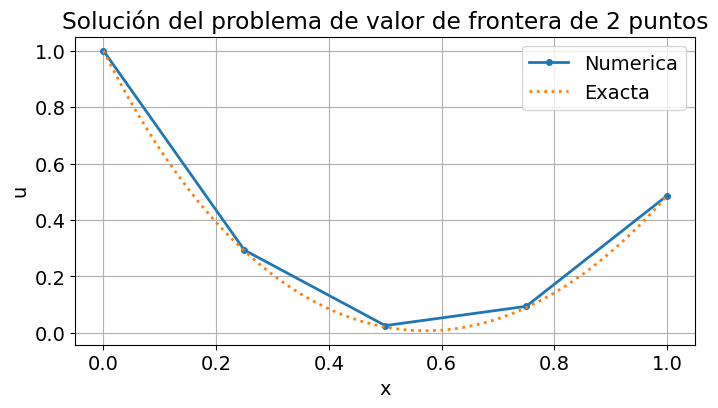

In [12]:
# Grafique la solución del problema de valor de frontera.
xe = np.linspace(0, 1, 101)
plt.plot(x, U, ".-")
plt.plot(xe, u_eksakt(xe), ":")
plt.xlabel("x")
plt.ylabel("u")
plt.legend(["Numerica", "Exacta"])
plt.title("Solución del problema de valor de frontera de 2 puntos");

Max error = 4.985e-03


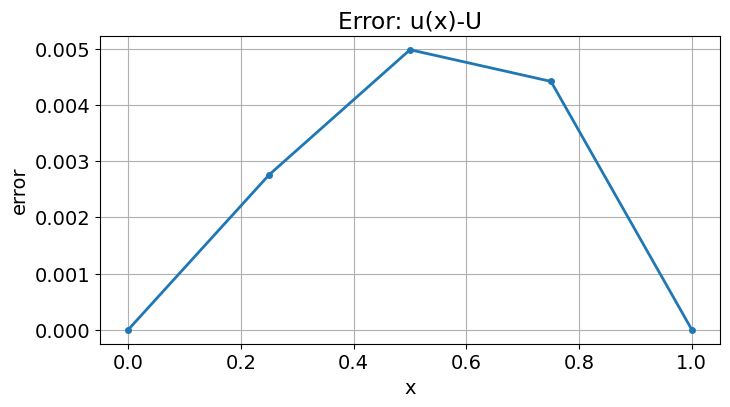

In [13]:
# Grafica el error |u(x)-U| en los puntos de la malla
error = np.abs(u_eksakt(x) - U)
plt.plot(x, error, ".-")
plt.xlabel("x")
plt.ylabel("error")
plt.title("Error: u(x)-U")
print("Max error = {:.3e}".format(max(abs(error))))

## Condiciones de frontera

Para obtener una solución única de un problema de valor de frontera (o una EDP),
se debe conocer cierta información sobre la solución, generalmente proporcionada
en la frontera.

Las condiciones de frontera más comunes son:
1. Condición de dirichlet: La solución se conoce en la frontera.
2. Condición de Neumann: La derivada se conoce en la frontera.
3. Condición de Robin (o mixta): Una combinación de estos dos últimos.

En el ejemplo anterior, se utilizaron las condiciones de Dirichlet.
Ahora veremos cómo manejar las condiciones de Neumann.
Las condiciones de Robin se pueden tratar de manera similar.

Dado el problema de valor de frontera con una condición de Neumann
en la frontera izquierda:
$$
u^{\prime\prime}+
p\left(x\right)u^{\prime}+
q\left(x\right)u=
r\left(x\right),\quad a\leq x\leq b,\quad u^{\prime}\left(a\right)=u^{\prime}_{a},
\quad u\left(b\right)=u_{b}.
$$

Aquí, $u^{\prime}_{a}$ es un valor dado.
En este caso, la solución $u\left(a\right)$ y su correspondiente 
aproximación $U_{0} $ son desconocidas y necesitamos alguna fórmula
de diferencia también para el punto $a=x_0$.
La opción más sencilla es utilizar una diferencia hacia adelante.
$$
u^{\prime}_{a}=
\frac{u\left(x_{1}\right)-u\left(x_{0}\right)}{h}+
\mathcal{O}\left(h\right)
\text{ resulting in }
\frac{U_{1}-U_{0}}{h}=u^{\prime}_{a}.
$$

Pero esto es sólo una aproximación de primer orden y, por lo tanto, se debe tener una precisión menor esperado.
También podríamos usar una aproximación de segundo orden usando los valores en el  puntos de la cuadrícula
$x_{0}$, $x_{1}$ y $x_{2}$, pero esto arruinará la bonita tridiagonal estructura de la matriz de coeficientes.

En su lugar, utilice la idea de una *frontera falsa*:

Supongamos que la solución se puede extender fuera de la frontera $x=a$,
hasta llegar a un punto de la malla ficticia $x_{-1}=a-h$, donde también asumimos
que hay una aproximación aproximada e igualmente ficticia $U_{-1}$ a $u\left(x_{-1}\right)$.

Entonces tenemos dos fórmulas de diferencia en el punto $a$, una para el problema de valor de frontera en sí y una diferencia central para las condiciones de frontera:

\begin{align*}
   \frac{U_{1}-2U_0+U_{-1}}{h^2} + p(x_0)\frac{U_{1}-U_{-1}}{2h} +    q(x_0) U_0 & =  r(x_0), \\ 
   \frac{U_1 - U_{-1}}{2h} &= u'_a.
\end{align*}

Ahora podemos resolver la segunda ecuación con respecto a $U_{-1}$ e insertar la solución en la primera ecuación.
Esto produce la nueva ecuación
$$
\frac{2U_{1}-2U_{0}-2hu^{\prime}_{a}}{h^2}+
p\left(x_{0}\right)u^{\prime}_{a}+
q\left(x_{0}\right)U_{0}=
r\left(x_{0}\right).
$$

Entonces lo único que ha cambiado es la primera ecuación.
Y dado que se han utilizado diferencias centrales tanto para el problema de valor de frontera
como para la condición de frontera, se puede demostrar que el orden general
de esta aproximación es $2$.

**Ejemplo 2:**

Consideramos el mismo ejemplo que antes, pero ahora con una condición de Neumann en la frontera izquierda.
$$
u^{\prime\prime}+2u^{\prime}-3u=9x,\quad
u^{\prime}\left(0\right)=u^{\prime}_{a}=-4,\quad
u\left(1\right)=u_{b}=-2e^{-3}+e-5
\approx 0.48635073,
$$
que tiene la solución analítica $u\left(x\right)=e^{-3x}-2e^{x}-3x-2$.
La ecuación en diferencias modificada en la frontera $x_{0}=0$ es
$$
\frac{2U_{1}-2U_{0}-2u^{\prime}_{a}h}{h^2}+
2u^{\prime}_{a}-3U_{0}=
0.
$$

Multiplicamos esta ecuación por $h^{2}$ e incluimos la ecuación como discretización
para el punto de la malla $x_{0}$.
Con esto obtenemos el sistema
\begin{align*}
 \left(-2-3h^{2}\right)U_{0}-2U_{1} &= \left(2h-2h^{2}\right)u^{\prime}_{a}, \\ 
 \left(1-h\right)U_{i-1}+\left(-2-3h^2\right)U_{i}+\left(1+h\right)U_{i+1} &=
 9h^{2}x_{i}, && i=1, \ldots N-1, \\ 
 U_{N} &= u_{b},
\end{align*}
que, para $N=4$ y $h=0.25$ se convierte en

$$
\begin{bmatrix}
-2.1875 & 2 & 0 & 0 & 0  \\ 
0.75 & -2.1875 & 1.25 & 0 & 0 \\ 
0 & 0.75 & -2.1875 & 1.25 & 0 \\ 
0 & 0 & 0.75 & -2.1875 & 1.25 \\ 
0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
U_{0} \\
U_{1} \\
U_{2} \\
U_{3} \\
U_{4}
\end{bmatrix}
\begin{bmatrix}
-1.5 \\
0.140625 \\
0.28125 \\ 
0.421875 \\
0.48635073
\end{bmatrix}.
$$

La solución del sistema lineal es
$$
U_{0}\approx 0.92103219,\quad
U_{1}\approx 0.25737896,\quad
U_{2}\approx 0.01029386,\quad
U_{3}\approx 0.08858688.
$$

**Problema 3:**

Consideremos ahora el problema de valor de frontera de dos puntos del Ejemplo 2; eso es,
$$
u^{\prime\prime}+
2u^{\prime}-
3u=9x,\quad
u^{\prime}\left(0\right)=u^{\prime}_{a}=-4,\quad
u\left(1\right)=u_{b}=-2e^{-3}+e-5
$$
que tiene la solución analítica $u\left(x\right)=e^{-3x}-2e^{x}-3x-2$.

Aquí queremos que pruebe las dos posibles implementaciones de las condiciones de
frontera de Neumann discutidas anteriormente.

**a)** Modifique la matriz $A$ y el lado derecho $b$ para implementar la condición de frontera de Neumann
$u^{\prime}\left(0\right)=u^{\prime}_{a}=-4$ a través de la aproximación
$u^{\prime}\left(a\right)\approx\frac{U_{1}-U_{0}}{h}=u^{\prime}_{a}$.
Ahora, utilizando la solución analítica, ejecute un estudio de convergencia en el Problema 2.
Grafique/escriba la tabla del orden de convergencia experimental resultante.
¿Qué orden de convergencia obtienes?

**b)** Ahora modifique la matriz $A$ y el lado derecho $b$ para implementar la condición de frontera de Neumann usando la idea de una frontera falsa como se describió anteriormente.
Rehaga el estudio de convergencia, grafique/escriba la tabla del orden de convergencia experimental resultante. 
¿Qué orden de convergencia obtienes esta vez?